In [2]:
import pandas as pd

df = pd.read_excel("ALL.xlsx")

df.head()

,Item_ID,Item,Construct,Bloom_Level,Bloom Action Verbs,DoK_Level,Lexical Diversity,Avg Sentence Length,Readability
0,HiBloom_1,Anne had a password in her phone represented b...,Numbers,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,NaN,NaN,NaN
1,HiBloom_2,Musoke had two wives one in Kanginima village ...,Data and Probability,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,NaN,NaN,NaN,NaN
2,HiBloom_3,On the last Sunday of the holiday Your uncle d...,Numbers,Create,Adapt; Assemble; Combine; Compile; Compose; Co...,NaN,NaN,NaN,NaN
3,HiBloom_4,"During their baking lesson, the students were ...",Patterns and Algebra,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,NaN,NaN,NaN
4,HiBloom_5,A certain member of your family re-wrote each ...,Geometry and Measures,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,NaN,NaN,NaN,NaN


In [3]:
import re

def lexical_diversity(text):
    words = re.findall(r'\b\w+\b', str(text).lower())
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df["Lexical Diversity"] = df["Item"].apply(lexical_diversity)

In [4]:
def avg_sentence_length(text):
    sentences = re.split(r'[.!?]+', str(text))
    sentences = [s for s in sentences if s.strip()]
    words = re.findall(r'\b\w+\b', str(text))
    
    if len(sentences) == 0:
        return 0
    
    return len(words) / len(sentences)

df["Avg Sentence Length"] = df["Item"].apply(avg_sentence_length)

In [7]:
%pip install textstat

Note: you may need to restart the kernel to use updated packages.


In [5]:
import textstat

df["Readability"] = df["Item"].apply(
    lambda x: textstat.flesch_reading_ease(str(x))
)

In [7]:
def assign_dok(bloom):
    bloom = str(bloom).lower()
    
    if bloom in ["remember"]:
        return 1
    elif bloom in ["understand", "apply"]:
        return 2
    elif bloom in ["analyze", "evaluate"]:
        return 3
    elif bloom in ["create"]:
        return 4
    else:
        return None

df["DoK_Level"] = df["Bloom_Level"].apply(assign_dok)

In [8]:
df.to_excel("ALL_with_features.xlsx", index=False)

In [9]:
import pandas as pd

df = pd.read_excel("ALL_with_features.xlsx")
df.head()

,Item_ID,Item,Construct,Bloom_Level,Bloom Action Verbs,DoK_Level,Lexical Diversity,Avg Sentence Length,Readability
0,HiBloom_1,Anne had a password in her phone represented b...,Numbers,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,0.672414,14.500000,71.012500
1,HiBloom_2,Musoke had two wives one in Kanginima village ...,Data and Probability,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,3.0,0.497268,11.437500,85.403763
2,HiBloom_3,On the last Sunday of the holiday Your uncle d...,Numbers,Create,Adapt; Assemble; Combine; Compile; Compose; Co...,4.0,0.595238,21.000000,70.476280
3,HiBloom_4,"During their baking lesson, the students were ...",Patterns and Algebra,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,0.543478,30.666667,42.694120
4,HiBloom_5,A certain member of your family re-wrote each ...,Geometry and Measures,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,3.0,0.554167,21.818182,67.882819


In [10]:
df['DoK_Level'].isnull().sum()

340

In [11]:
# Mapping Bloom_Level → DoK_Level
dok_mapping = {
    "Remember": 1,
    "Understand": 1,
    "Apply": 2,
    "Analyse": 3,
    "Analyze": 3,   # accounting for spelling
    "Evaluate": 3,
    "Create": 4
}

# Fill missing DoK_Level using mapping
df['DoK_Level'] = df['DoK_Level'].fillna(df['Bloom_Level'].map(dok_mapping))

# Confirm all missing values are filled
print("Missing DoK values now:", df['DoK_Level'].isnull().sum())

Missing DoK values now: 340


In [12]:
df['Bloom_Level'].unique()

array(['Analyse ', 'Evaluate', 'Create'], dtype=object)

In [13]:
df['Bloom_Level'] = df['Bloom_Level'].str.strip().str.capitalize()

In [14]:
df['DoK_Level'] = df['DoK_Level'].fillna(df['Bloom_Level'].map(dok_mapping))

In [15]:
print("Missing DoK values now:", df['DoK_Level'].isnull().sum())

Missing DoK values now: 0


In [16]:
df.isnull().sum()

Item_ID                0
Item                   0
Construct              0
Bloom_Level            0
Bloom Action Verbs     0
DoK_Level              0
Lexical Diversity      0
Avg Sentence Length    0
Readability            0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Item_ID              1019 non-null   object 
 1   Item                 1019 non-null   object 
 2   Construct            1019 non-null   object 
 3   Bloom_Level          1019 non-null   object 
 4   Bloom Action Verbs   1019 non-null   object 
 5   DoK_Level            1019 non-null   float64
 6   Lexical Diversity    1019 non-null   float64
 7   Avg Sentence Length  1019 non-null   float64
 8   Readability          1019 non-null   float64
dtypes: float64(4), object(5)
memory usage: 71.8+ KB


In [18]:
df.shape

(1019, 9)

In [19]:
# Basic info
df.info()

# Summary statistics for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Item_ID              1019 non-null   object 
 1   Item                 1019 non-null   object 
 2   Construct            1019 non-null   object 
 3   Bloom_Level          1019 non-null   object 
 4   Bloom Action Verbs   1019 non-null   object 
 5   DoK_Level            1019 non-null   float64
 6   Lexical Diversity    1019 non-null   float64
 7   Avg Sentence Length  1019 non-null   float64
 8   Readability          1019 non-null   float64
dtypes: float64(4), object(5)
memory usage: 71.8+ KB


,DoK_Level,Lexical Diversity,Avg Sentence Length,Readability
count,1019.000000,1019.000000,1019.000000,1019.000000
mean,3.332679,0.532696,18.748266,64.563741
std,0.471404,0.076078,6.350260,13.039055
min,3.000000,0.180879,3.653061,0.592700
25%,3.000000,0.485604,14.641711,56.721423
50%,3.000000,0.531579,17.750000,66.266106
75%,4.000000,0.579129,21.333333,73.591816
max,4.000000,0.826087,64.500000,97.107500


In [30]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [20]:
%pip install prince

   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ------------- -------------------------- 262.1/795.4 kB ? eta -:--:--
   ------------- -------------------------- 262.1/795.4 kB ? eta -:--:--
   ---------------------------------------  786.4/795.4 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 795.4/795.4 kB 1.0 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.2 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.1 MB 1.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.1 MB 1.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.1 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:05
   --------- ------------------------

  You can safely remove it manually.


In [24]:
import pandas as pd
import prince
from sklearn.impute import SimpleImputer

# Clean column names
df.columns = df.columns.str.strip()

# Define columns
numeric_columns = ['Lexical Diversity', 'Avg Sentence Length', 'Readability']
categorical_columns = ['Bloom_Level', 'DoK_Level']

# Select dataset safely
data = df[numeric_columns + categorical_columns].copy()

# Impute numeric missing values
imputer = SimpleImputer(strategy='mean')
data[numeric_columns] = imputer.fit_transform(data[numeric_columns])

# Convert categorical features
data[categorical_columns] = data[categorical_columns].astype('category')

# Apply FAMD
famd = prince.FAMD(n_components=2, random_state=42)
famd_features = famd.fit_transform(data)

# Add projection to original dataframe
df['FAMD1'] = famd_features[0]
df['FAMD2'] = famd_features[1]

print(df[['FAMD1','FAMD2']].head())

      FAMD1     FAMD2
0 -0.978327 -0.718976
1 -0.633436 -2.201710
2  1.961697  0.319889
3 -1.381195  2.421121
4 -0.993975 -0.074202


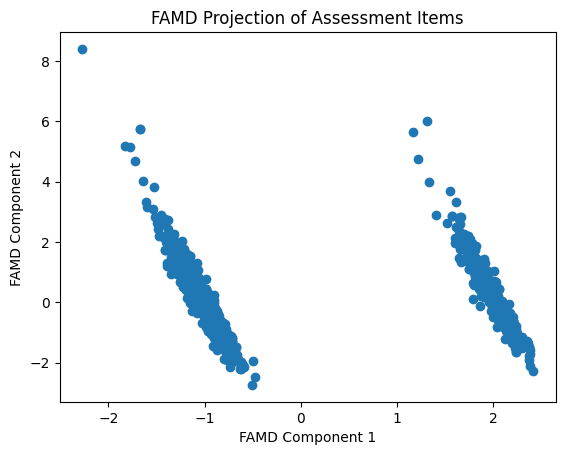

In [25]:
import matplotlib.pyplot as plt

plt.scatter(df['FAMD1'], df['FAMD2'])
plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")
plt.title("FAMD Projection of Assessment Items")
plt.show()

In [26]:
%pip install kmodes

Note: you may need to restart the kernel to use updated packages.


In [29]:
from kmodes.kprototypes import KPrototypes
import numpy as np

# Select columns used for clustering
numeric_columns = ['Lexical Diversity', 'Avg Sentence Length', 'Readability']
categorical_columns = ['Bloom_Level', 'DoK_Level']

# Prepare dataset
data_cluster = df[numeric_columns + categorical_columns].copy()

# Convert categorical columns to string (required by K-Prototypes)
for col in categorical_columns:
    data_cluster[col] = data_cluster[col].astype(str)

# Convert to numpy array
data_matrix = data_cluster.to_numpy()

# Identify categorical column indexes
categorical_index = [data_cluster.columns.get_loc(col) for col in categorical_columns]

# Run K-Prototypes
kproto = KPrototypes(n_clusters=4, init='Cao', random_state=42)

clusters = kproto.fit_predict(data_matrix, categorical=categorical_index)

# Add cluster labels to dataframe
df['Cluster'] = clusters

print(df[['Cluster']].head())
# Numeric summary
numeric_summary = df.groupby('Cluster')[[
    'Lexical Diversity',
    'Avg Sentence Length',
    'Readability'
]].mean()

# Categorical summary
categorical_summary = df.groupby('Cluster')[[
    'Bloom_Level',
    'DoK_Level'
]].agg(lambda x: x.mode()[0])

print(numeric_summary)
print(categorical_summary)

   Cluster
0        3
1        1
2        3
3        2
4        3
         Lexical Diversity  Avg Sentence Length  Readability
Cluster                                                     
0                 0.549153            20.368199    53.154259
1                 0.524144            14.898747    78.384653
2                 0.523962            29.552981    37.623609
3                 0.530845            18.510418    66.480547
        Bloom_Level  DoK_Level
Cluster                       
0          Evaluate        3.0
1            Create        3.0
2           Analyse        3.0
3           Analyse        3.0


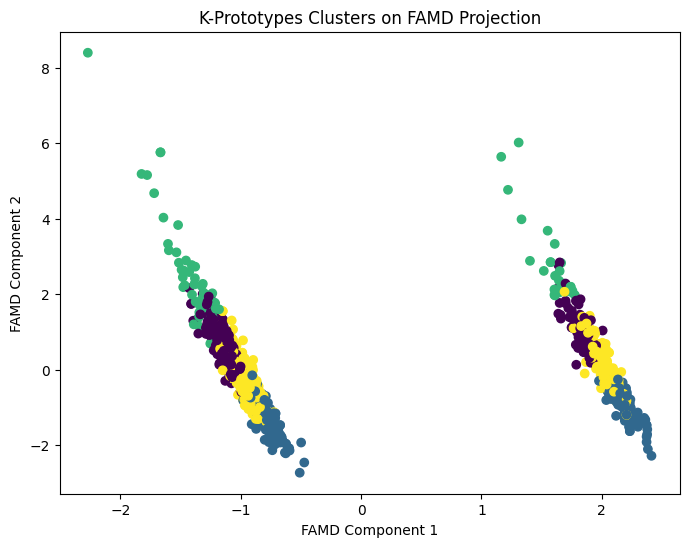

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['FAMD1'],
    df['FAMD2'],
    c=df['Cluster']
)

plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")
plt.title("K-Prototypes Clusters on FAMD Projection")

plt.show()

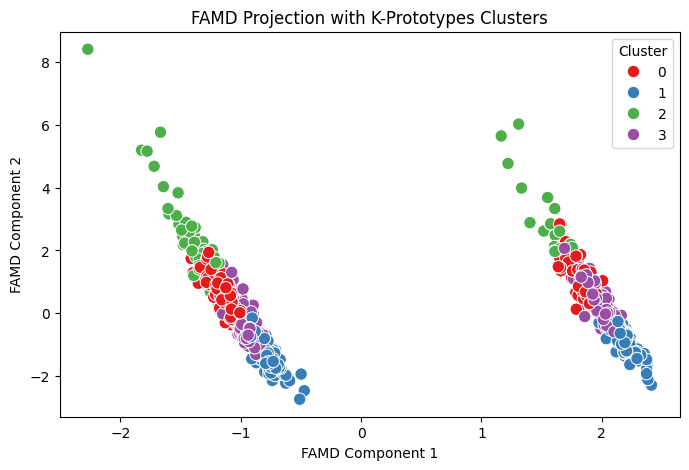

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='FAMD1', y='FAMD2', 
    hue='Cluster', 
    data=df, 
    palette='Set1', 
    s=80
)
plt.title("FAMD Projection with K-Prototypes Clusters")
plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")
plt.show()

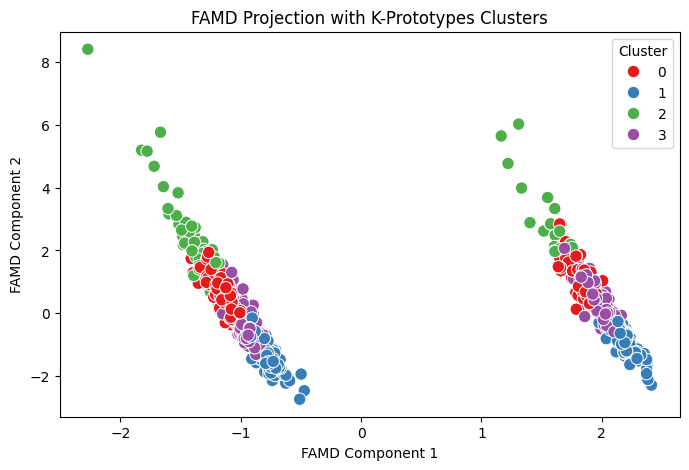

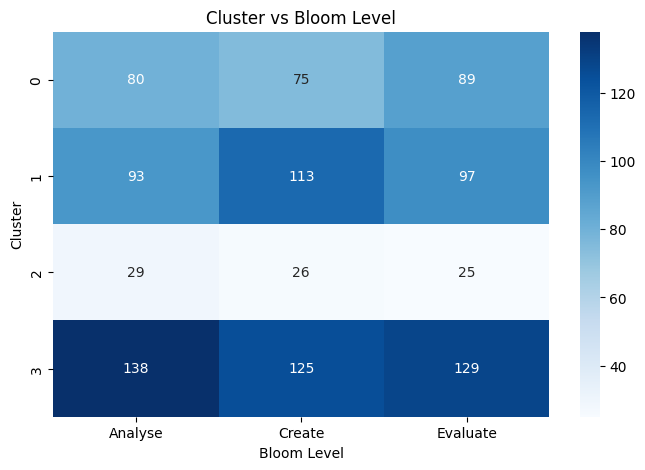

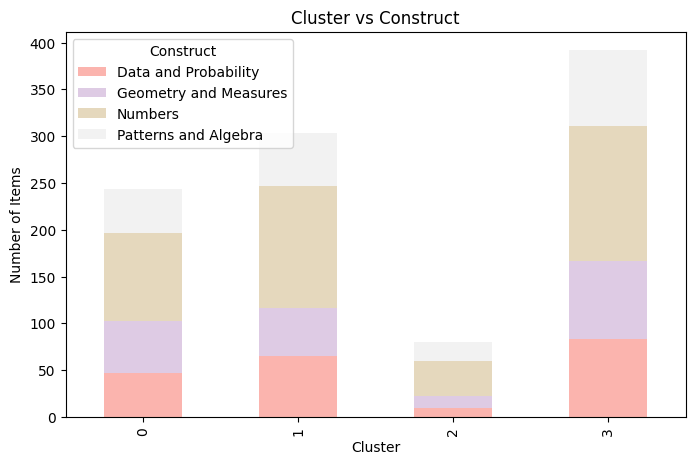

C:\Users\nanyu\AppData\Local\Temp\ipykernel_16396\3845808408.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Lexical Diversity', data=df, palette='Set3')


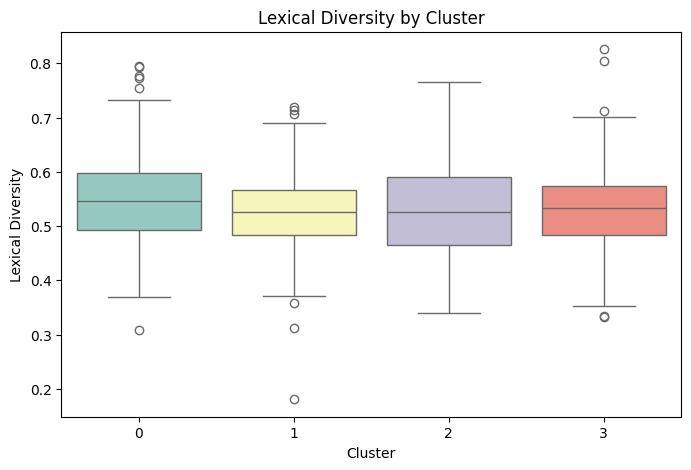

C:\Users\nanyu\AppData\Local\Temp\ipykernel_16396\3845808408.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Avg Sentence Length', data=df, palette='Set2')


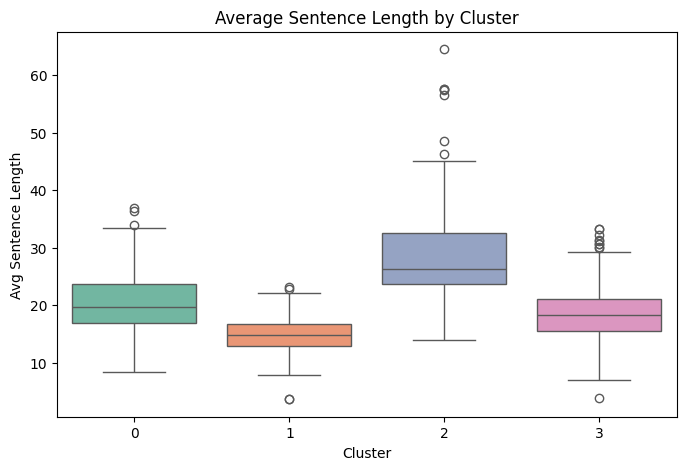

C:\Users\nanyu\AppData\Local\Temp\ipykernel_16396\3845808408.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Readability', data=df, palette='Set1')


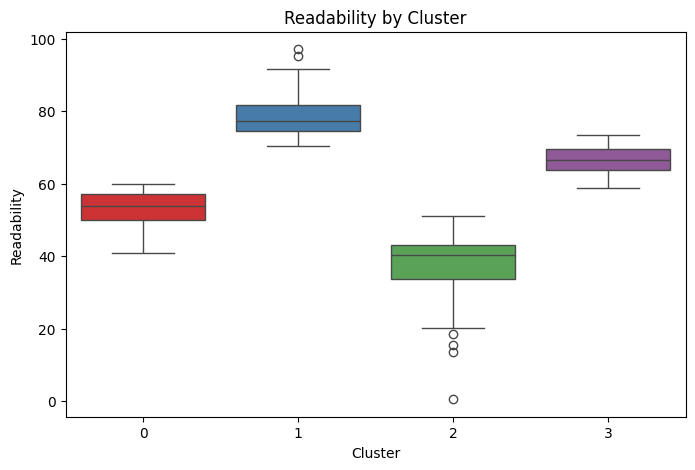

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Scatter Plot: FAMD Projection with K-Prototypes Clusters ---
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='FAMD1', y='FAMD2', 
    hue='Cluster', 
    data=df, 
    palette='Set1',
    s=80
)
plt.title("FAMD Projection with K-Prototypes Clusters")
plt.xlabel("FAMD Component 1")
plt.ylabel("FAMD Component 2")
plt.legend(title='Cluster')
plt.show()

# --- 2. Heatmap: Cluster vs Bloom Level ---
cross_bloom = pd.crosstab(df['Cluster'], df['Bloom_Level'])
plt.figure(figsize=(8,5))
sns.heatmap(cross_bloom, annot=True, cmap='Blues', fmt='d')
plt.title("Cluster vs Bloom Level")
plt.xlabel("Bloom Level")
plt.ylabel("Cluster")
plt.show()

# --- 3. Stacked Bar Chart: Cluster vs Construct ---
cross_construct = pd.crosstab(df['Cluster'], df['Construct'])
cross_construct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Pastel1')
plt.title("Cluster vs Construct")
plt.xlabel("Cluster")
plt.ylabel("Number of Items")
plt.show()

# --- 4. Boxplot: Lexical Diversity by Cluster ---
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Lexical Diversity', data=df, palette='Set3')
plt.title("Lexical Diversity by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Lexical Diversity")
plt.show()

# --- 5. Boxplot: Avg Sentence Length by Cluster ---
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Avg Sentence Length', data=df, palette='Set2')
plt.title("Average Sentence Length by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Avg Sentence Length")
plt.show()

# --- 6. Boxplot: Readability by Cluster ---
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Readability', data=df, palette='Set1')
plt.title("Readability by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Readability")
plt.show()

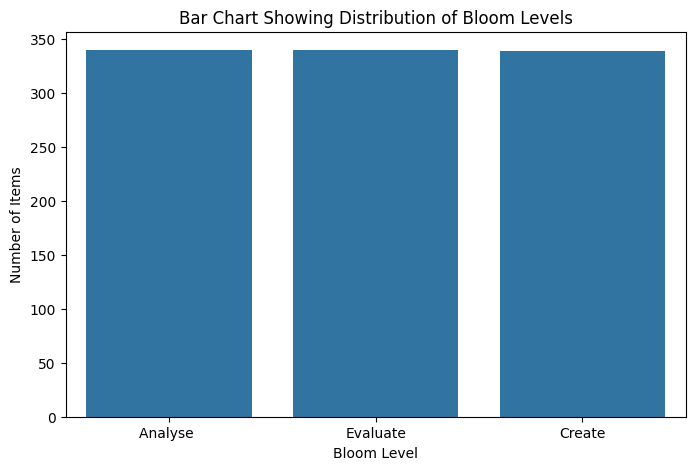

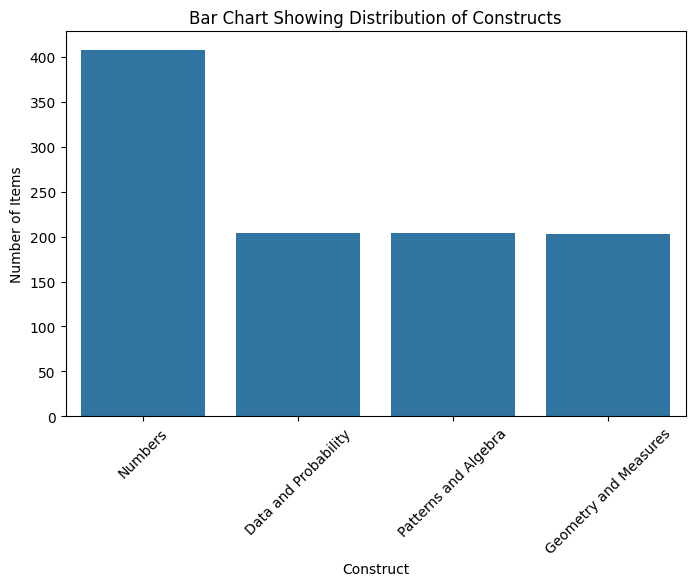

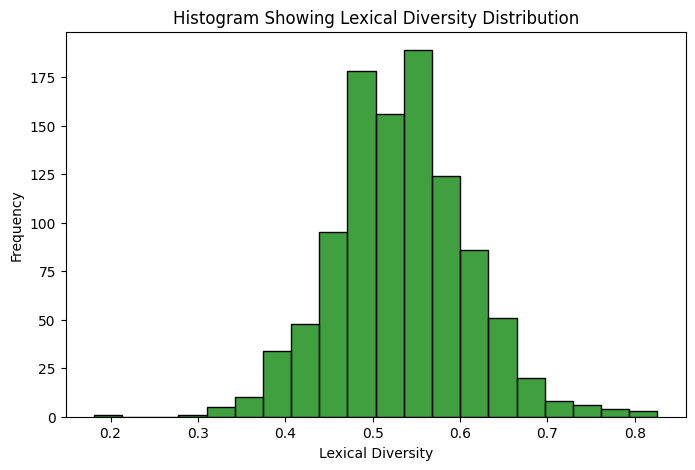

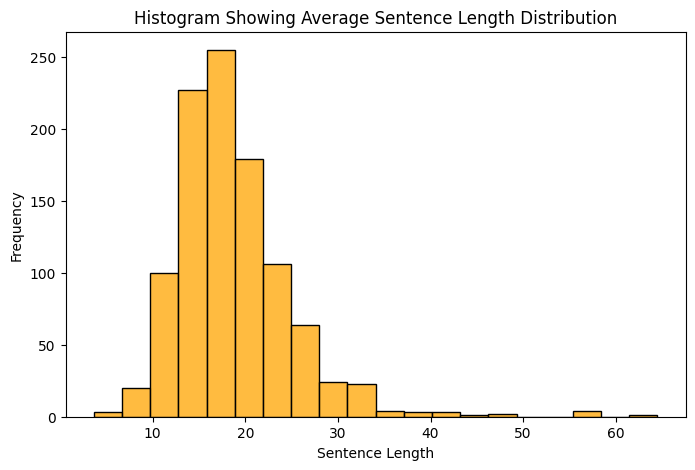

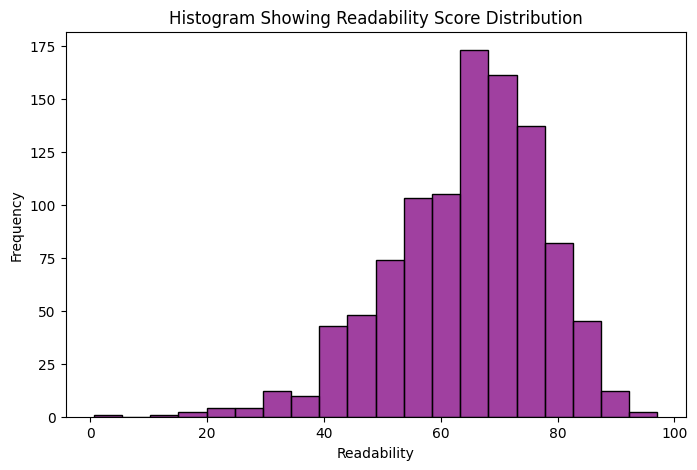

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_excel("ALL_with_features.xlsx")

plt.figure(figsize=(8,5))
sns.countplot(x='Bloom_Level', data=df)
plt.title("Bar Chart Showing Distribution of Bloom Levels")
plt.xlabel("Bloom Level")
plt.ylabel("Number of Items")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Construct', data=df)
plt.title("Bar Chart Showing Distribution of Constructs")
plt.xlabel("Construct")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Lexical Diversity'], bins=20, color='green')
plt.title("Histogram Showing Lexical Diversity Distribution")
plt.xlabel("Lexical Diversity")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(df['Avg Sentence Length'], bins=20, color='orange')
plt.title("Histogram Showing Average Sentence Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Readability'], bins=20, color='purple')
plt.title("Histogram Showing Readability Score Distribution")
plt.xlabel("Readability")
plt.ylabel("Frequency")
plt.show()

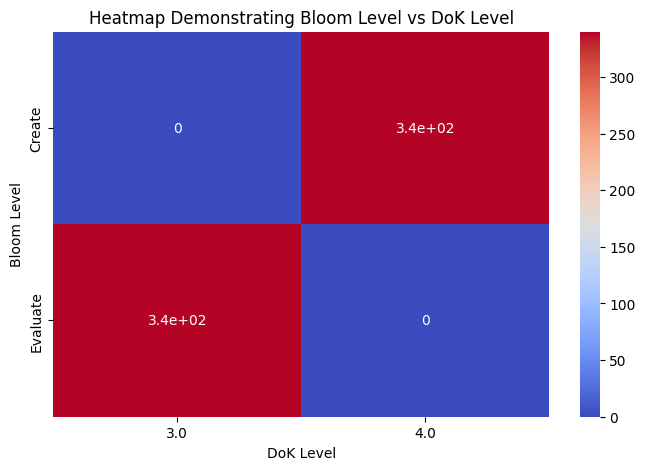

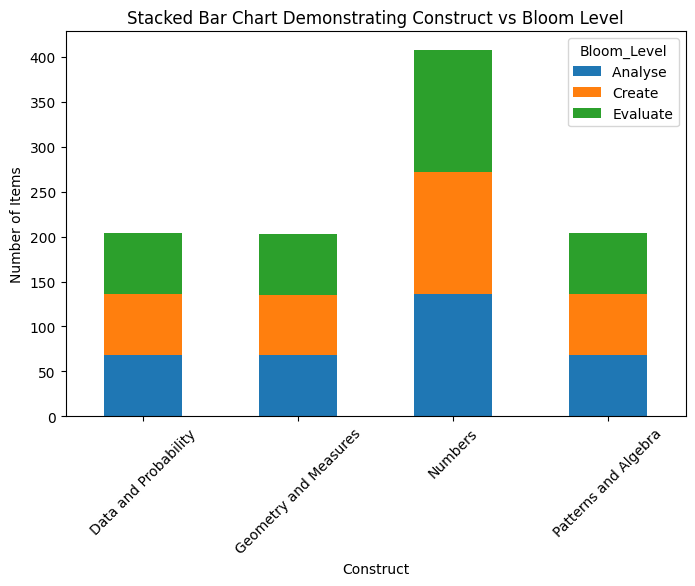

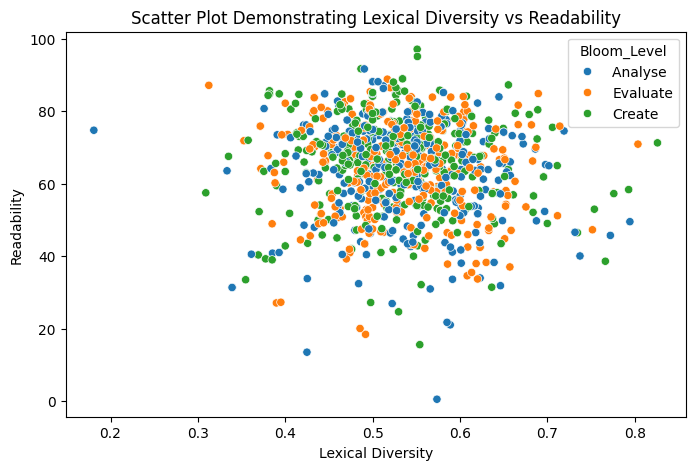

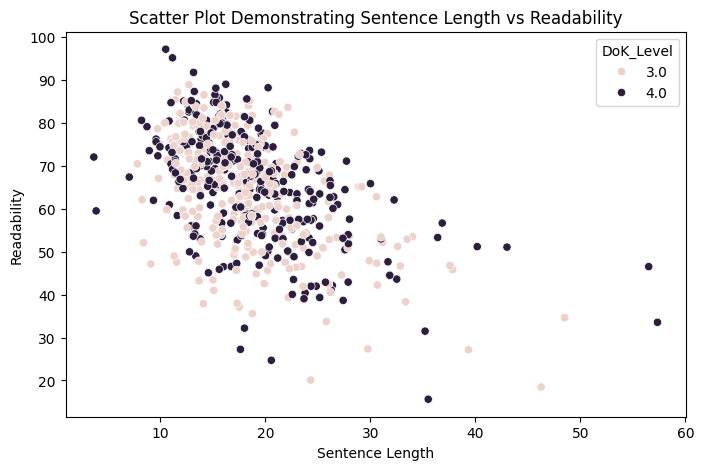

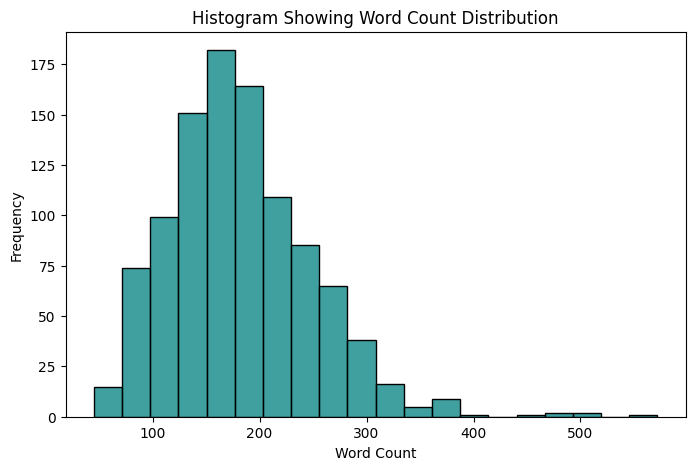

In [34]:

cross = pd.crosstab(df['Bloom_Level'], df['DoK_Level'])
plt.figure(figsize=(8,5))
sns.heatmap(cross, annot=True, cmap='coolwarm')
plt.title("Heatmap Demonstrating Bloom Level vs DoK Level")
plt.xlabel("DoK Level")
plt.ylabel("Bloom Level")
plt.show()

cross = pd.crosstab(df['Construct'], df['Bloom_Level'])
cross.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Stacked Bar Chart Demonstrating Construct vs Bloom Level")
plt.xlabel("Construct")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Lexical Diversity', y='Readability', data=df, hue='Bloom_Level')
plt.title("Scatter Plot Demonstrating Lexical Diversity vs Readability")
plt.xlabel("Lexical Diversity")
plt.ylabel("Readability")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Avg Sentence Length', y='Readability', data=df, hue='DoK_Level')
plt.title("Scatter Plot Demonstrating Sentence Length vs Readability")
plt.xlabel("Sentence Length")
plt.ylabel("Readability")
plt.show()

df['Word_Count'] = df['Item'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(df['Word_Count'], bins=20, color='teal')
plt.title("Histogram Showing Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [40]:
import pandas as pd
from kmodes.kprototypes import KPrototypes

# Columns
numeric_columns = ['Lexical Diversity', 'Avg Sentence Length', 'Readability']
categorical_columns = ['Bloom_Level', 'DoK_Level']

# 1. Impute missing values
# Numeric: fill with mean
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Categorical: fill with mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Prepare data for K-Prototypes
data_matrix = df[numeric_columns + categorical_columns].to_numpy()

# 3. Categorical indices relative to subset
cat_idx = [3, 4]  # positions of categorical columns in data_matrix

# 4. Fit K-Prototypes
kproto = KPrototypes(n_clusters=4, init='Huang', random_state=42)
clusters = kproto.fit_predict(data_matrix, categorical=cat_idx)
df['Cluster'] = clusters

print(df[['Cluster'] + numeric_columns + categorical_columns].head())

   Cluster  Lexical Diversity  Avg Sentence Length  Readability Bloom_Level  \
0        0           0.672414            14.500000    71.012500    Analyse    
1        3           0.497268            11.437500    85.403763    Evaluate   
2        0           0.595238            21.000000    70.476280      Create   
3        1           0.543478            30.666667    42.694120    Analyse    
4        0           0.554167            21.818182    67.882819    Evaluate   

  DoK_Level  
0       3.0  
1       3.0  
2       4.0  
3       3.0  
4       3.0  


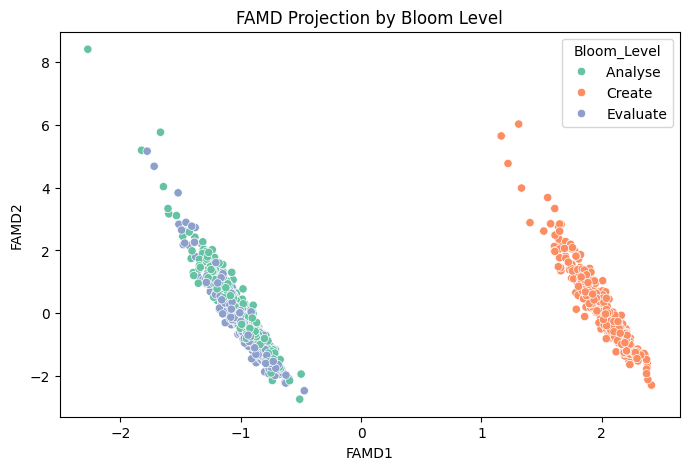

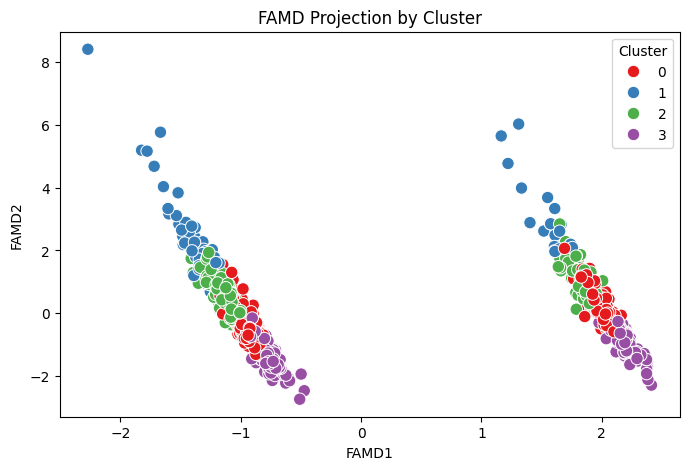

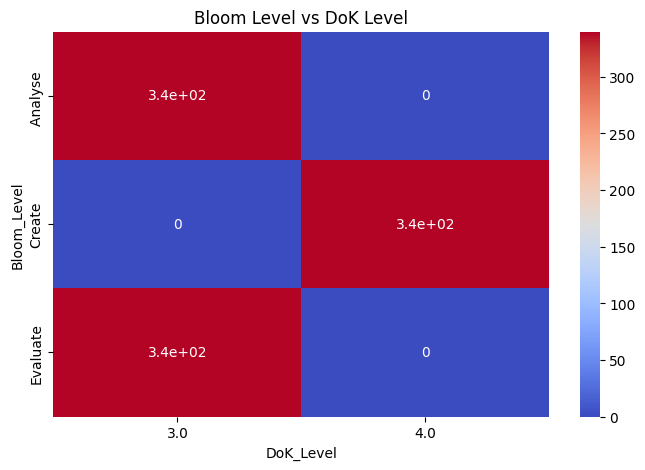

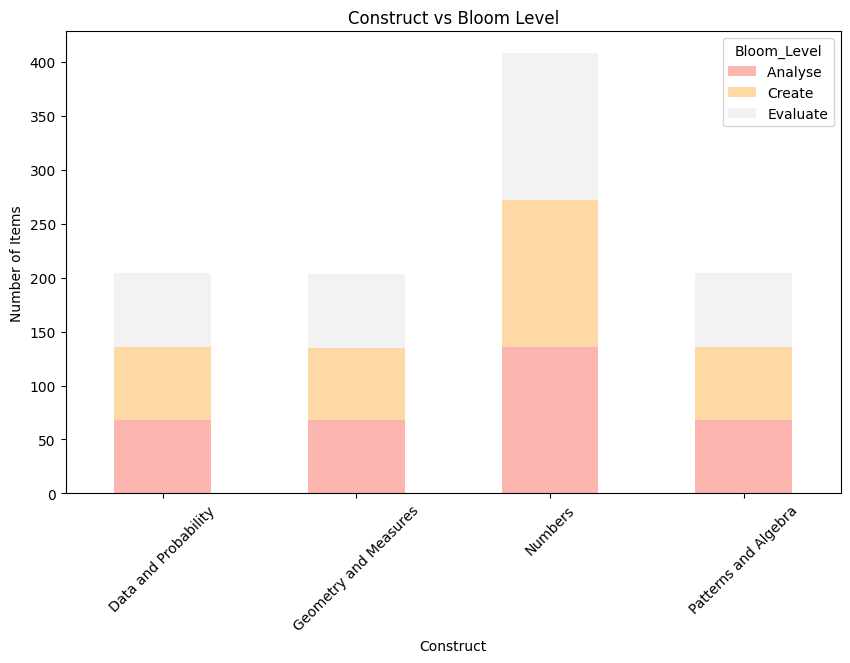

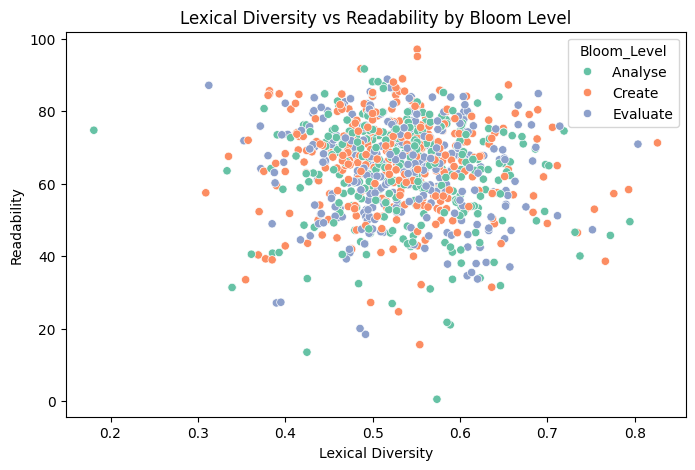

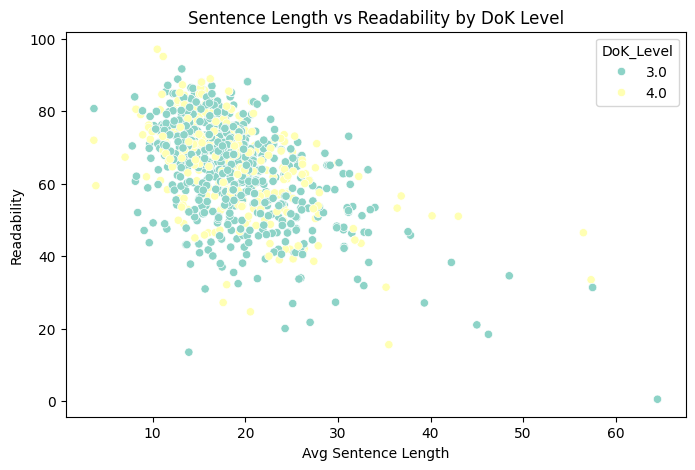

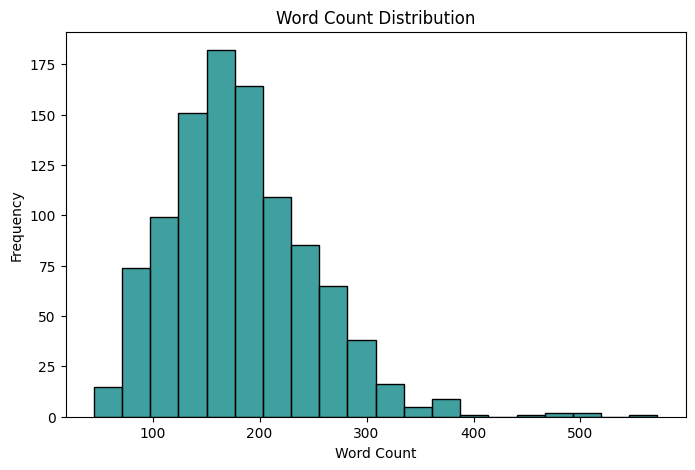

C:\Users\nanyu\AppData\Local\Temp\ipykernel_16396\2638661325.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set3')


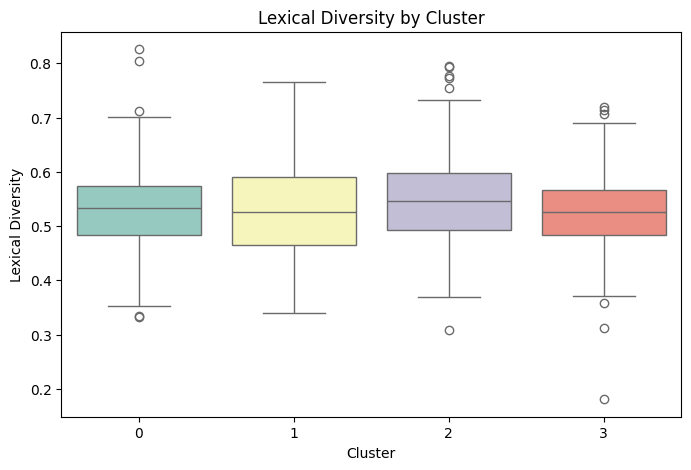

C:\Users\nanyu\AppData\Local\Temp\ipykernel_16396\2638661325.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set3')


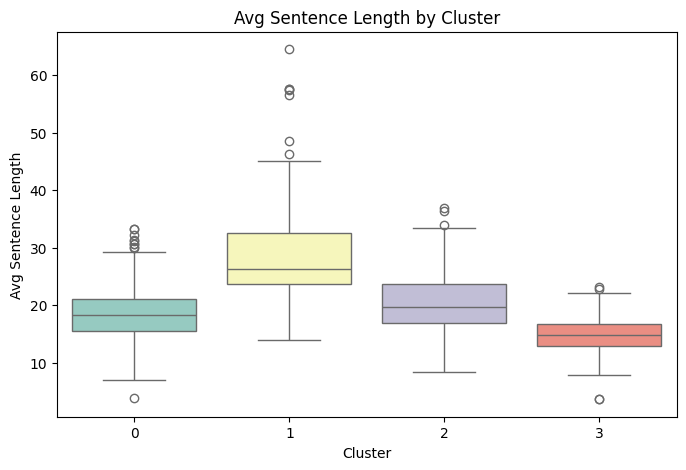

C:\Users\nanyu\AppData\Local\Temp\ipykernel_16396\2638661325.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set3')


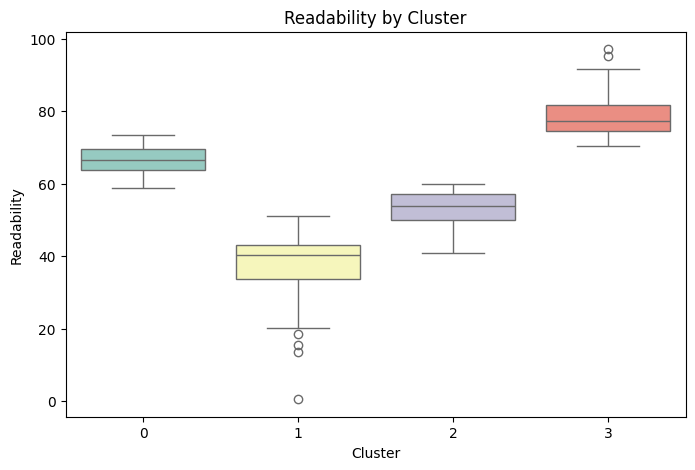

=== Cluster Numeric Summary ===
         Lexical Diversity  Avg Sentence Length  Readability
Cluster                                                     
0                 0.530845            18.510418    66.480547
1                 0.523962            29.552981    37.623609
2                 0.549153            20.368199    53.154259
3                 0.524144            14.898747    78.384653

=== Cluster Categorical Summary ===
        Bloom_Level DoK_Level
Cluster                      
0          Analyse        3.0
1          Analyse        3.0
2          Evaluate       3.0
3            Create       3.0


In [46]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from kmodes.kprototypes import KPrototypes
from prince import FAMD  # for mixed data dimensionality reduction

# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_excel("ALL_with_features.xlsx")

# ===============================
# 3. Preprocessing
# ===============================
numeric_columns = ['Lexical Diversity', 'Avg Sentence Length', 'Readability']
categorical_columns = ['Bloom_Level', 'DoK_Level']

# Impute numeric columns
num_imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = num_imputer.fit_transform(df[numeric_columns])

# Impute categorical columns (replace NaN with mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = cat_imputer.fit_transform(df[categorical_columns])
df[categorical_columns] = df[categorical_columns].astype('category')

# ===============================
# 4. FAMD for Mixed Data Projection
# ===============================
famd = FAMD(n_components=2, random_state=42)
famd_features = famd.fit_transform(df[numeric_columns + categorical_columns])

df['FAMD1'] = famd_features.iloc[:, 0]
df['FAMD2'] = famd_features.iloc[:, 1]

# ===============================
# 5. K-Prototypes Clustering
# ===============================
# Prepare data for K-Prototypes
data_matrix = df[numeric_columns + categorical_columns].to_numpy()

# Categorical column indices relative to data_matrix
cat_idx = [len(numeric_columns) + i for i in range(len(categorical_columns))]  # e.g., [3,4]

# Run K-Prototypes
kproto = KPrototypes(n_clusters=4, init='Huang', random_state=42)
clusters = kproto.fit_predict(data_matrix, categorical=cat_idx)
df['Cluster'] = clusters

# ===============================
# 6. Visualizations
# ===============================
plt.figure(figsize=(8,5))
sns.scatterplot(x='FAMD1', y='FAMD2', hue='Bloom_Level', data=df, palette='Set2')
plt.title("FAMD Projection by Bloom Level")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='FAMD1', y='FAMD2', hue='Cluster', data=df, palette='Set1', s=80)
plt.title("FAMD Projection by Cluster")
plt.show()

cross = pd.crosstab(df['Bloom_Level'], df['DoK_Level'])
plt.figure(figsize=(8,5))
sns.heatmap(cross, annot=True, cmap='coolwarm')
plt.title("Bloom Level vs DoK Level")
plt.show()

cross = pd.crosstab(df['Construct'], df['Bloom_Level'])
cross.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Pastel1')
plt.title("Construct vs Bloom Level")
plt.xlabel("Construct")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Lexical Diversity', y='Readability', data=df, hue='Bloom_Level', palette='Set2')
plt.title("Lexical Diversity vs Readability by Bloom Level")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Avg Sentence Length', y='Readability', data=df, hue='DoK_Level', palette='Set3')
plt.title("Sentence Length vs Readability by DoK Level")
plt.show()

df['Word_Count'] = df['Item'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(df['Word_Count'], bins=20, color='teal')
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

for col in numeric_columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Cluster', y=col, data=df, palette='Set3')
    plt.title(f"{col} by Cluster")
    plt.show()

# ===============================
# 7. Cluster Summary
# ===============================
summary_numeric = df.groupby('Cluster')[numeric_columns].mean()
summary_categorical = df.groupby('Cluster')[categorical_columns].agg(lambda x: x.mode()[0])

print("=== Cluster Numeric Summary ===")
print(summary_numeric)
print("\n=== Cluster Categorical Summary ===")
print(summary_categorical)

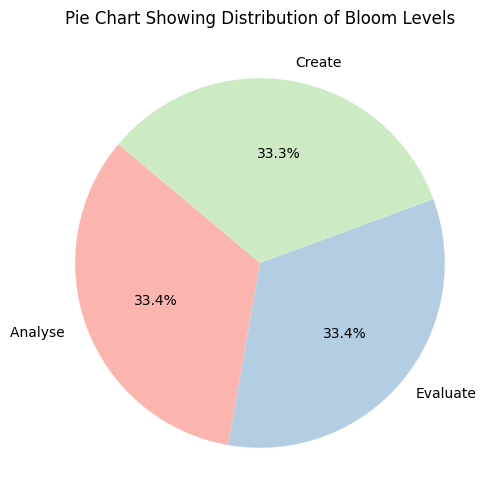

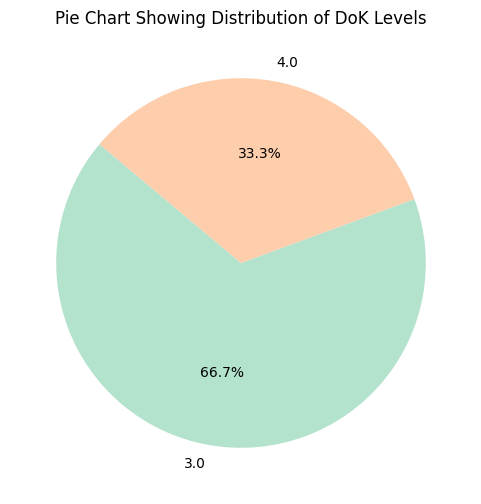

In [45]:
import matplotlib.pyplot as plt

bloom_counts = df['Bloom_Level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(bloom_counts, labels=bloom_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title("Pie Chart Showing Distribution of Bloom Levels")
plt.show()

dok_counts = df['DoK_Level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(dok_counts, labels=dok_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel2.colors)
plt.title("Pie Chart Showing Distribution of DoK Levels")
plt.show()

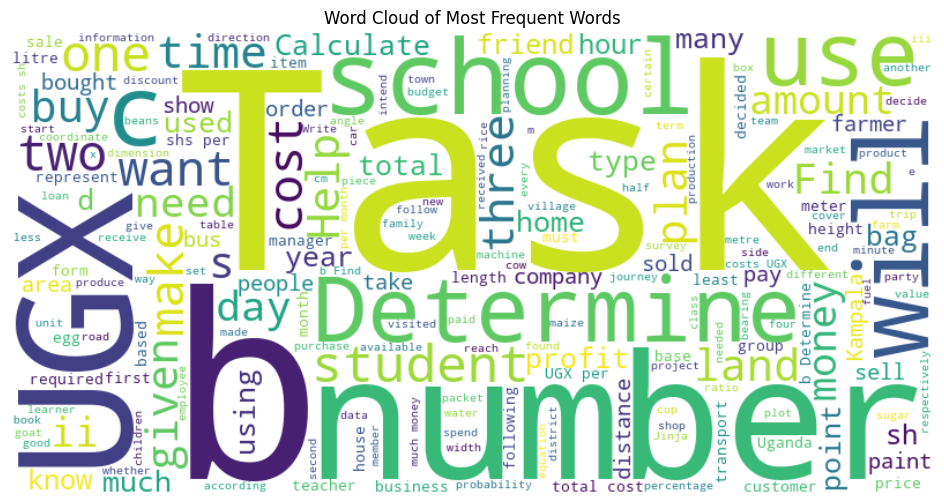

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text from the 'Item' column
text = " ".join(df['Item'].astype(str))

# Create Word Cloud
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Most Frequent Words")
plt.show()